c:\Users\USER\.conda\envs\vlm\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


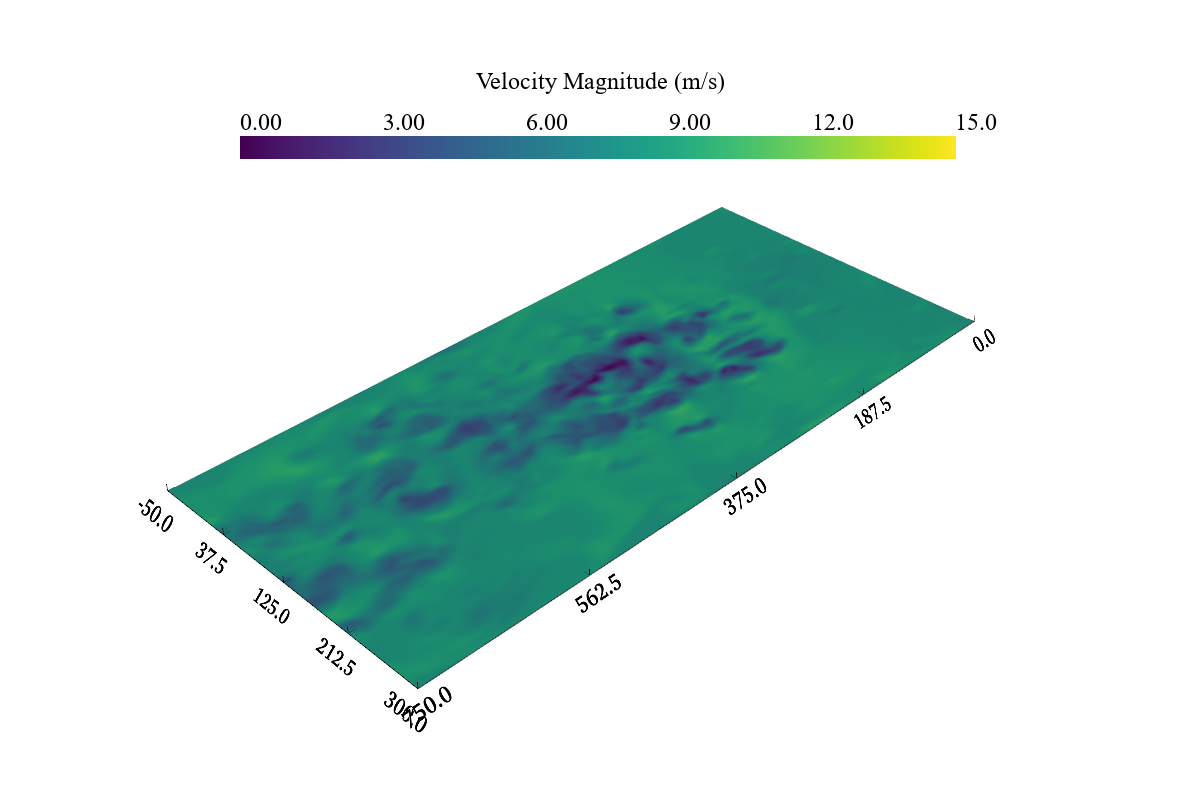

In [6]:
import pyvista as pv
import numpy as np

# Read both meshes
mesh_bp = pv.read(r"../../wind/vtk_resampled/resampled_75.vtk")

slice_x_bp = mesh_bp.slice(normal='z', origin=(0, 0, 50))
clipped_slice_bp = slice_x_bp.clip(normal=[0, 0, -1], origin=[0, 0, 0])

combined_U = clipped_slice_bp.get_array('U')
clipped_slice_bp['U'] = combined_U


glyphs = clipped_slice_bp.glyph(
   orient='U',              
   scale='U',              
   factor=0.2,             
   geom=pv.Arrow()         
)

plotter = pv.Plotter()

plotter.add_mesh(clipped_slice_bp, 
               opacity=1.0,
               cmap='viridis',
               clim=[0, 15],
               show_scalar_bar=False,
               )

bar = plotter.add_scalar_bar(
    title='Velocity Magnitude (m/s)\n',
    n_labels=6,
    title_font_size=24,
    label_font_size=24,
    position_x=0.2,
    position_y=0.80,
    font_family='times',
)

bar.GetTitleTextProperty().SetLineSpacing(1.01)

for _tp in (bar.GetTitleTextProperty(), bar.GetLabelTextProperty()):
    _tp.SetFontFamily(4)
    _tp.SetFontFile(r'C:\Windows\Fonts\times.ttf')

plotter.show_bounds(
   show_xaxis=True,
   xtitle=" ",
   show_yaxis=True,
   ytitle=" ",
   show_zaxis=True,
   ztitle=" ",
   show_zlabels=True,
   show_xlabels=True,
   show_ylabels=True,
   location='outer',
   font_family='times',
)

plotter.window_size = [1200, 800]
plotter.camera.zoom(1.1)
plotter.show()
